In [33]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from src import corpus,keymap,optimization

from tqdm import tqdm
import numpy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
char_freqs,bigram_matrix,chars=corpus.get_matrix_from_json("ressources/fre_en.json")
print(len(chars))
ergo_chords=keymap.generate_ergonomic_chords(3)
print(len(ergo_chords))

POP_SIZE =200  # Population size for genetic algorithm
GENS = 90  # Number of generations
MUTATION_RATE = 0.5  # Probability of mutation
MAX_MUTATION=10
IND_SIZE=len(ergo_chords)
layout_cost=lambda layout: (float(optimization.layout_cost(layout,char_freqs,bigram_matrix,ergo_chords)),)
mutate= lambda child: (keymap.mutate(child,MUTATION_RATE,MAX_MUTATION),)
crossover= lambda p1,p2:(keymap.crossover(p1, p2),keymap.crossover(p2, p1))


36
92


In [43]:
import random

from deap import base
from deap import creator
from deap import tools

from deap import algorithms

# creator.create("FitnessMin", base.Fitness, weights=(1.0,))
# creator.create("Individual", list, fitness=creator.FitnessMin)

creator.create("Fitness", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.Fitness)

toolbox = base.Toolbox()
# toolbox.register("attr_int", random.random)
# toolbox.register("individual", random.sample,list(range(IND_SIZE)), IND_SIZE)


# toolbox = base.Toolbox()
toolbox.register("indices", random.sample, range(IND_SIZE), IND_SIZE)
toolbox.register("individual", tools.initIterate, creator.Individual,
                 toolbox.indices)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", layout_cost)
toolbox.register("mate", crossover)
toolbox.register("mutate", mutate)
toolbox.register("select", tools.selNSGA2)

In [44]:
random.seed(64)
NGEN = GENS
MU = POP_SIZE
LAMBDA = 100
CXPB = 0.7
MUTPB = 0.2

pop = toolbox.population(n=MU)
hof = tools.ParetoFront()
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", numpy.mean, axis=0)
stats.register("std", numpy.std, axis=0)
stats.register("min", numpy.min, axis=0)
stats.register("max", numpy.max, axis=0)

algorithms.eaMuPlusLambda(pop, toolbox, MU, LAMBDA, CXPB, MUTPB, NGEN, stats,
                            halloffame=hof)

pop, stats, hof

gen	nevals	avg          	std          	min          	max          
0  	200   	[59.38617524]	[11.63581864]	[30.40795134]	[95.58735873]


AttributeError: 'list' object has no attribute 'fitness'

In [38]:
mutate(pop[0])

([60,
  15,
  80,
  78,
  51,
  68,
  2,
  26,
  34,
  89,
  25,
  18,
  10,
  53,
  56,
  81,
  3,
  79,
  87,
  0,
  8,
  22,
  13,
  5,
  33,
  28,
  76,
  11,
  75,
  49,
  29,
  65,
  57,
  69,
  82,
  47,
  71,
  35,
  27,
  70,
  32,
  19,
  77,
  23,
  44,
  31,
  67,
  64,
  63,
  72,
  14,
  61,
  74,
  58,
  41,
  43,
  17,
  38,
  90,
  1,
  50,
  88,
  30,
  36,
  86,
  9,
  7,
  20,
  59,
  21,
  91,
  24,
  52,
  4,
  55,
  83,
  37,
  48,
  62,
  40,
  85,
  45,
  16,
  84,
  39,
  42,
  73,
  6,
  46,
  66,
  54,
  12],)

In [39]:
layout_cost(pop[0])

(60.595599550130494,)

In [37]:
crossover(pop[0],pop[1])

([60,
  15,
  13,
  78,
  51,
  68,
  2,
  26,
  34,
  89,
  25,
  18,
  10,
  53,
  56,
  81,
  3,
  79,
  87,
  0,
  8,
  22,
  80,
  5,
  33,
  28,
  76,
  11,
  75,
  49,
  29,
  65,
  57,
  69,
  45,
  47,
  71,
  35,
  27,
  70,
  32,
  19,
  77,
  23,
  44,
  31,
  67,
  64,
  63,
  72,
  14,
  61,
  74,
  58,
  41,
  43,
  17,
  38,
  90,
  1,
  50,
  88,
  30,
  36,
  86,
  9,
  7,
  20,
  59,
  21,
  91,
  24,
  52,
  4,
  55,
  83,
  37,
  48,
  62,
  40,
  85,
  82,
  16,
  84,
  39,
  42,
  73,
  6,
  46,
  66,
  54,
  12],
 [60,
  15,
  80,
  68,
  2,
  26,
  34,
  25,
  18,
  53,
  56,
  81,
  3,
  79,
  0,
  8,
  22,
  39,
  13,
  5,
  33,
  28,
  76,
  11,
  75,
  49,
  29,
  65,
  57,
  69,
  82,
  47,
  71,
  10,
  35,
  27,
  70,
  32,
  19,
  77,
  23,
  44,
  31,
  67,
  64,
  63,
  72,
  14,
  61,
  74,
  58,
  41,
  43,
  51,
  17,
  38,
  90,
  1,
  89,
  50,
  88,
  30,
  36,
  86,
  9,
  7,
  66,
  20,
  59,
  21,
  91,
  24,
  4,
  55,
  83,
  37,
  48,
  78

Text(0.5, 1.0, '0.10051995668838358')

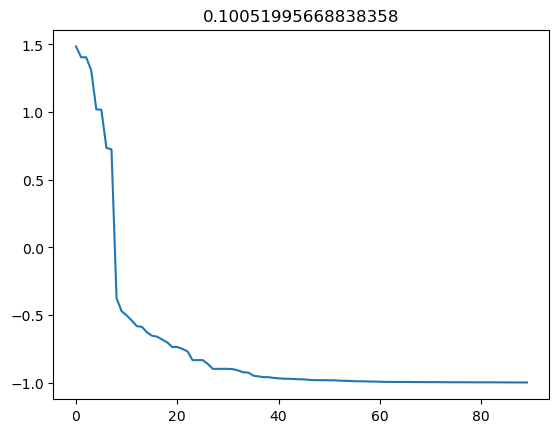

In [274]:
plt.plot(np.log10(best_score))
plt.title(best_score[-1])

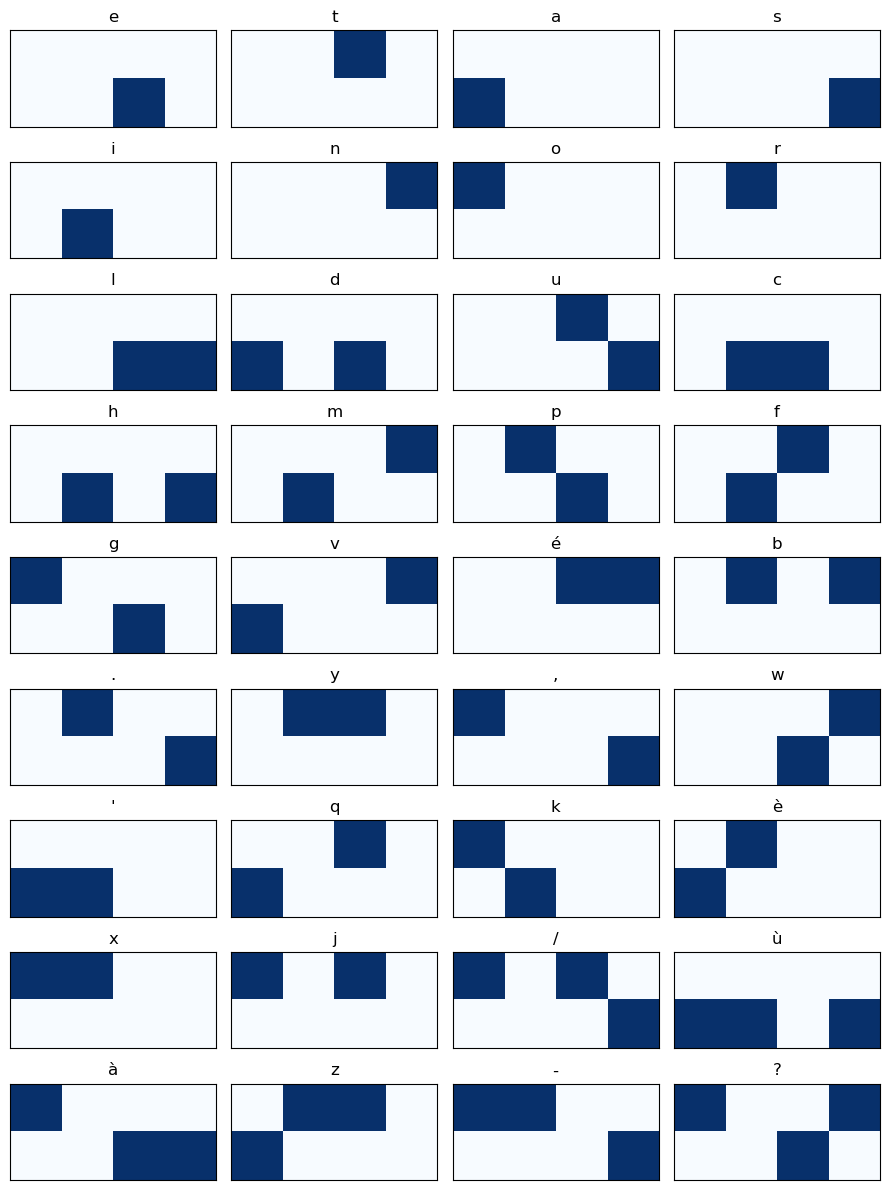

In [275]:
# keymap.plot_layout(best_layout,ergo_chords,chars)
keymap.plot_layout_nicer(best_layout,ergo_chords,chars)